In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/code/compositional`


In [2]:
using DataFrames, JLD2, StatsBase, QuadGK
using CSV, CodecZlib, LaTeXStrings
using CairoMakie, MakiePublication
using Statistics, Random, Distributions, SpecialFunctions

In [3]:
include("./utils.jl")
using .Utils

In [4]:
# Set theme for plots
__theme = MakiePublication.theme_acs(; ishollowmarkers=[true,true])
set_theme!(__theme)

In [5]:
# Root that contains domains
root = "./Data/arx_sources"

# domain -> topic -> samples (each sample = Vector{String} lines)
domains = Dict{String, Dict{String, Vector{Vector{String}}}}()

for domain_dir in filter(isdir, readdir(root; join=true))
    domain = splitpath(domain_dir)[end]
    topic_map = Dict{String, Vector{Vector{String}}}()

    for topic_dir in filter(isdir, readdir(domain_dir; join=true))
        topic = splitpath(topic_dir)[end]
        texts_dir = joinpath(topic_dir, "texts")
        if !isdir(texts_dir); continue; end

        txt_files = filter(f -> endswith(f, ".txt"), readdir(texts_dir; join=true))
        if isempty(txt_files); continue; end

        topic_map[topic] = [readlines(f) for f in txt_files]
    end

    if !isempty(topic_map)
        domains[domain] = topic_map
    end
end


Domains are: **astro-ph**, **hep**, **nucl**, **math**

In [6]:
# Create a DataFrame with words counts for all domains and topics
df = DataFrame(
    domain = String[],
    env = String[],
    species_id = String[],
    sample_id = Int[],
    count = Int[],
    nreads = Int[]
)

for (domain, topics) in domains
    for (topic, samples) in topics
        for (i,sample) in enumerate(samples)
            # Clean each word: keep only letters/numbers
            clean_sample = [replace(w, r"^[^A-Za-z0-9]+|[^A-Za-z0-9]+$" => "") for w in sample]
            
            # Remove empty or short words
            clean_sample = filter(!isempty, clean_sample)
        
            # Count words
            cnt_map = countmap(clean_sample)
            for (k,v) in cnt_map
                push!(df, (domain, topic, k, i, v, sum(values(cnt_map))))
            end
        end
    end
end

# Remove stopwords
STOPWORDS = Set([
    "me","my","myself","we","our","ours","ourselves","you","your","yours","yourself","yourselves","he","him","his","himself",
    "she","her","hers","herself","it","its","itself","hey","them","their","theirs","themselves","what","which","who","whom",
    "this","that","these","those","am","is","are","was","were","be","been","being","have","has","had","having","do","does","did",
    "doing","an","the","and","but","if","or","because","as","until","while","of","at","by","for","with","about","against","between",
    "into","through","during","before","after","above","below","to","from","up","down","in","out","on","off","over","under","again",
    "further","then","once","here","there","when","where","why","how","all","any","both","each","few","more","most","other","some",
    "such","no","nor","not","only","own","same","so","than","too","very","can","will","just","don","should","now",
    "a","b","c","d","e","f","g","h","i","j","k","l","m","n","o","p","q","r","s","t","u","v", "w","x","y","z"
])

filter!(row -> !(row.species_id in STOPWORDS), df);

In [7]:
# Create different dfs for the different scales
agg0 = deepcopy(df)
agg0.env .= agg0.domain .* "-" .* agg0.env
select!(agg0, [:env, :species_id, :sample_id, :count, :nreads])

agg1 = select(df, [:domain, :species_id, :sample_id, :count, :nreads])
rename!(agg1, :domain => :env)

agg2 = select(df, [:species_id, :sample_id, :count, :nreads])
agg2.env .= "Math&Physics";

In [8]:
df = deepcopy(agg1)
Utils.df_filter!(df; min_samples=5e1, min_nreads=5e3)

println("--- AFD ---")
afd = Utils.compute_AFD(df; occ=0.99, bins=30, plot=false, verbose=true, save=false);

--- AFD ---
math
astro-ph
hep
nucl


In [9]:
function gamma_params(df; occ=0.99)
    freqs = Utils.get_frequencies(df; occ = occ, rescale=false)
    μv = mean(freqs, dims=1)
    σv = std(freqs, dims=1)
    βv = μv .^ 2 ./ σv .^ 2
    return mean(βv), std(βv)
end

function betap_params(df; occ=0.99)
    freqs = Utils.get_frequencies(df; occ = occ, rescale=false)
    μv = mean(freqs, dims=1)
    σv = std(freqs, dims=1)
    θ = mean(μv) # THIS IS AN ANSATZ
    βv = μv .^ 2 ./ σv .^ 2 .+ μv .* θ ./ σv .^ 2 .+ 2
    αv = μv .^ 3 ./ σv .^ 2 ./ θ .+ μv .^ 2 ./ σv .^ 2 .+ μv ./ θ
    return mean(αv), std(αv), mean(βv), std(βv)
end

betap_params (generic function with 1 method)

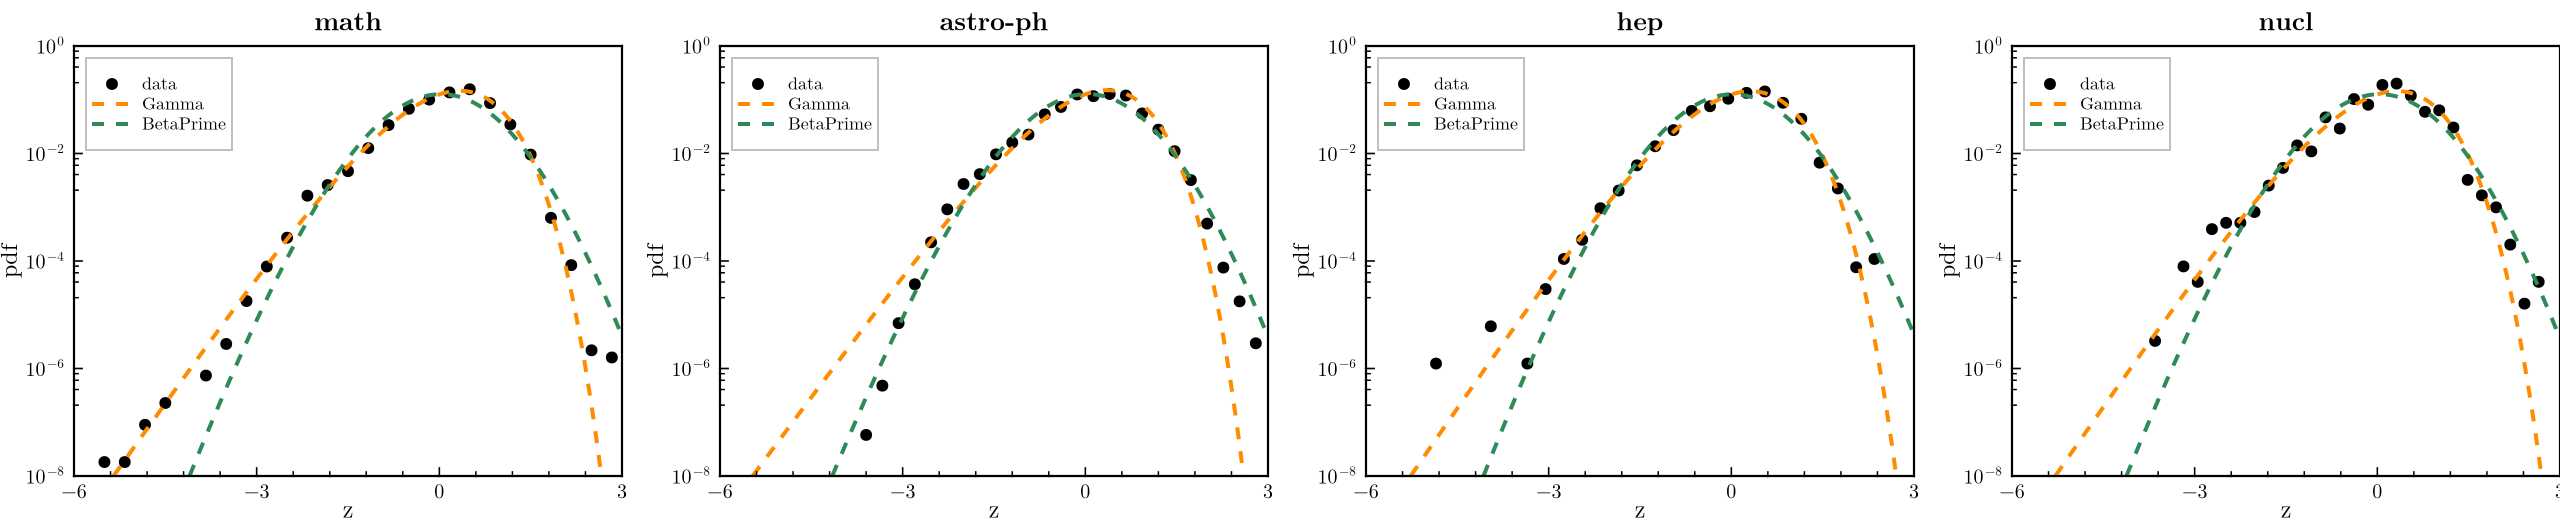

In [10]:
# Plot AFDs

# Collect environment names in a robust way
envs = afd isa AbstractDict ? collect(keys(afd)) : [e for (e, _) in afd]
nenv  = length(envs)

ncols = 4
if nenv == 1
    ncols =1
end
nrows = cld(nenv, ncols)            # ceil division
fig   = Figure(size=(320*ncols, 260*nrows))

# Global axis settings
xlims = (-6, 3)
ylims = (1e-8, 1e0)
zrange = -6:1e-2:3

for (i, e) in enumerate(envs)
    row = (i - 1) ÷ ncols + 1
    col = (i - 1) % ncols + 1
    ax = Axis(fig[row, col];
        title = string(e),
        yscale = log10,
        limits = (xlims, ylims),
        xlabel = L"\text{z}",
        ylabel = L"\text{pdf}",
        xlabelsize = 12, ylabelsize = 12, titlesize = 13,
        xticklabelsize = 10, yticklabelsize = 10
    )

    # Data for this environment
    x, y = afd isa AbstractDict ? afd[e] : only(last.(filter(p -> first(p) == e, afd)))

    # Parameters for this environment
    k, sk = gamma_params(df[df.env .== e, :], occ=0.99)
    α, sα, β, sβ = betap_params(df[df.env .== e, :], occ=0.99)

    # Plots
    scatter!(ax, x, 10 .^ log.(y); markersize=7, label="data", color=:black)

    lines!(ax, zrange, 10 .^ Utils.lr_gamma(zrange, k);
           linewidth=2, linestyle=:dash, label="Gamma", color=:darkorange)
    
    lines!(ax, zrange, 10 .^ Utils.lr_betap(zrange, α, β);
           linewidth=2, linestyle=:dash, label="BetaPrime", color=:seagreen)
    
    # Legend inside each axis
    axislegend(ax; position=:lt, framevisible=true, labelsize=9, padding=3)
end

# Optional: tighten layout a bit
colgap!(fig.layout, 12)
rowgap!(fig.layout, 10)

fig


In [11]:
# ---- Stats from CDF values (unchanged) ----
function gof_stats_from_u(u::AbstractVector{<:Real})
    n = length(u)
    ϵ = 1e-12
    u = clamp.(u, ϵ, 1 - ϵ)

    i = collect(1:n)
    ω2 = 1/(12n) + sum(((2 .* i .- 1) ./ (2n) .- u).^2)
    A2 = -n - (1/n) * sum( (2 .* i .- 1) .* (log.(u) .+ log.(1 .- reverse(u))) )
    D  = maximum( max.((i ./ n) .- u, u .- ((i .- 1) ./ n)) )
    return ω2, A2, D
end

# ---- Data → stats given F and parameters θ... ----
function gof_stats_data(data, F, θ...)
    x = sort(collect(data))
    u = map(xi -> F(xi, θ...), x)
    return gof_stats_from_u(u)
end

# ---- Bootstrap p-values (expects rand_custom(n, θ...) or rand_custom(rng, n, θ...)) ----
function gof_pvalues_bootstrap(data, F, rand_custom, θ...; nsim::Int=2000)
    n = length(data)
    ω2_obs, A2_obs, D_obs = gof_stats_data(data, F, θ...)

    ω2_sim = Vector{Float64}(undef, nsim)
    A2_sim = similar(ω2_sim)
    D_sim  = similar(ω2_sim)

    for s in 1:nsim
        xs = sort(rand_custom(n, θ...))
        us = map(xi -> F(xi, θ...), xs)
        ω2_sim[s], A2_sim[s], D_sim[s] = gof_stats_from_u(us)
    end

    return (p_cvm = mean(ω2_sim .>= ω2_obs),
            p_ad  = mean(A2_sim .>= A2_obs),
            p_ks  = mean(D_sim  .>= D_obs))
end


gof_pvalues_bootstrap (generic function with 1 method)

In [13]:
# Collect environment names in a robust way
envs = afd isa AbstractDict ? collect(keys(afd)) : [e for (e, _) in afd]
nenv  = length(envs)

# Custom CDF
G(x, k) = quadgk(t -> exp(Utils.lr_gamma(t, k)), -Inf, x)[1]
BP(x, α, β) = quadgk(t -> exp(Utils.lr_betap(t, α, β)), -Inf, x)[1]

# Custom sampling
function rand_gamma(n::Integer, α::Real)
    x = rand(Gamma(α, 1.0), n)
    return (log.(x) .- digamma(α)) ./ sqrt(trigamma(α))
end

function rand_betap(n::Integer, α::Real, β::Real)
    x = rand(BetaPrime(α, β), n)
    return (log.(x) .- digamma(α) .+ digamma(β)) ./ sqrt(trigamma(α) + trigamma(β))
end

for (i, e) in enumerate(envs)
    println("--- $e ---")
    
    # Data for this environment
    freqs = Utils.get_frequencies(df[df.env .== e, :], occ=0.99)
    log_non_zero = [log.(col[col .> 0]) for col in eachcol(freqs)]
    μ = mean.(log_non_zero)
    σ = std.(log_non_zero)
    allz = vcat([(x .- μ[j]) ./ σ[j] for (j, x) in enumerate(log_non_zero)]...)
    allz = allz[.!isnan.(allz)]

    # Parameters for this environment
    k, sk = gamma_params(df[df.env .== e, :], occ=0.99)
    α, sα, β, sβ = betap_params(df[df.env .== e, :], occ=0.99)
    
    # Compute statistic test
    println("Gamma statistic")
    stats = gof_pvalues_bootstrap(allz, G, rand_gamma, k; nsim=1000)
    @show stats

    println("BetaPrime statistic")
    stats = gof_pvalues_bootstrap(allz, BP, rand_betap, α, β; nsim=1000)
    @show stats
    println()
end

--- math ---
Gamma statistic
stats = (p_cvm = 0.77, p_ad = 0.489, p_ks = 0.719)
BetaPrime statistic
stats = (p_cvm = 0.0, p_ad = 0.0, p_ks = 0.0)

--- astro-ph ---
Gamma statistic
stats = (p_cvm = 0.0, p_ad = 0.0, p_ks = 0.0)
BetaPrime statistic
stats = (p_cvm = 0.0, p_ad = 0.0, p_ks = 0.0)

--- hep ---
Gamma statistic
stats = (p_cvm = 0.941, p_ad = 0.907, p_ks = 0.833)
BetaPrime statistic
stats = (p_cvm = 0.011, p_ad = 0.007, p_ks = 0.005)

--- nucl ---
Gamma statistic
stats = (p_cvm = 0.586, p_ad = 0.481, p_ks = 0.337)
BetaPrime statistic
stats = (p_cvm = 0.019, p_ad = 0.01, p_ks = 0.002)

